# HUB4049 DEEP LEARNING FOR MEDICAL IMAGING CLASSIFICATION 
# DATASET : Pneumonia 

## Step1 : Load data 
For this step we will load the medmnist data and split in to various section of training, validation and test data. then wnat to creaste data loaders for the for ech section with an approarite batch size. We will then produce some visulaization of data belonging to ecah section.

In [41]:
pip install --user torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


In [42]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio

In [43]:
import sys
print(sys.executable)

C:\Users\Student\anaconda3\python.exe


In [44]:
import sys
!{sys.executable} -m pip install medmnist

  Training samples   : 4708
  Validation samples : 524
  Test samples       : 624

DataLoaders created with batch_size=32
  Train batches : 148
  Val batches   : 17
  Test batches  : 20

Sample batch → images shape : torch.Size([32, 1, 28, 28])
Sample batch → labels shape : torch.Size([32, 1])
Unique label values in batch : [0, 1]
Figure saved → C:\Users\Student\Documents\tadala_main\HUB4049\fig1_class_examples.png


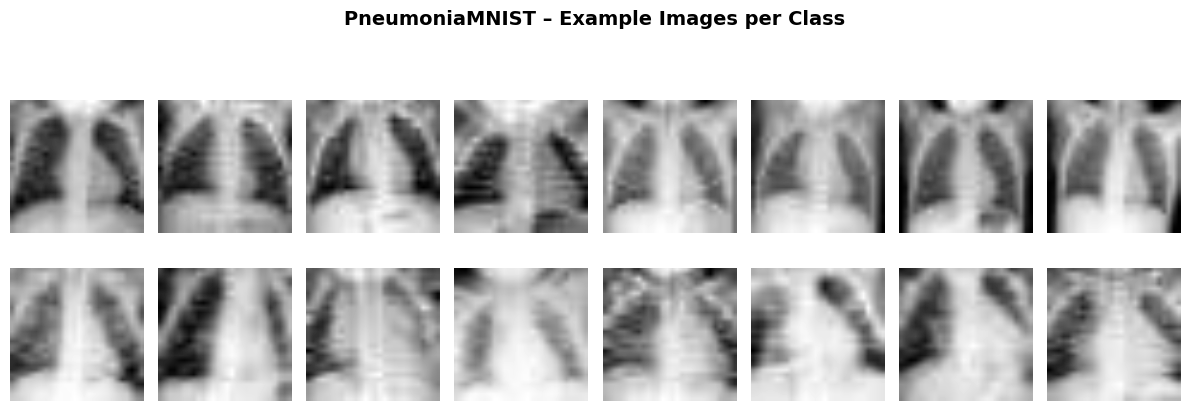

Figure saved → C:\Users\Student\Documents\tadala_main\HUB4049\fig1_class_examples.png


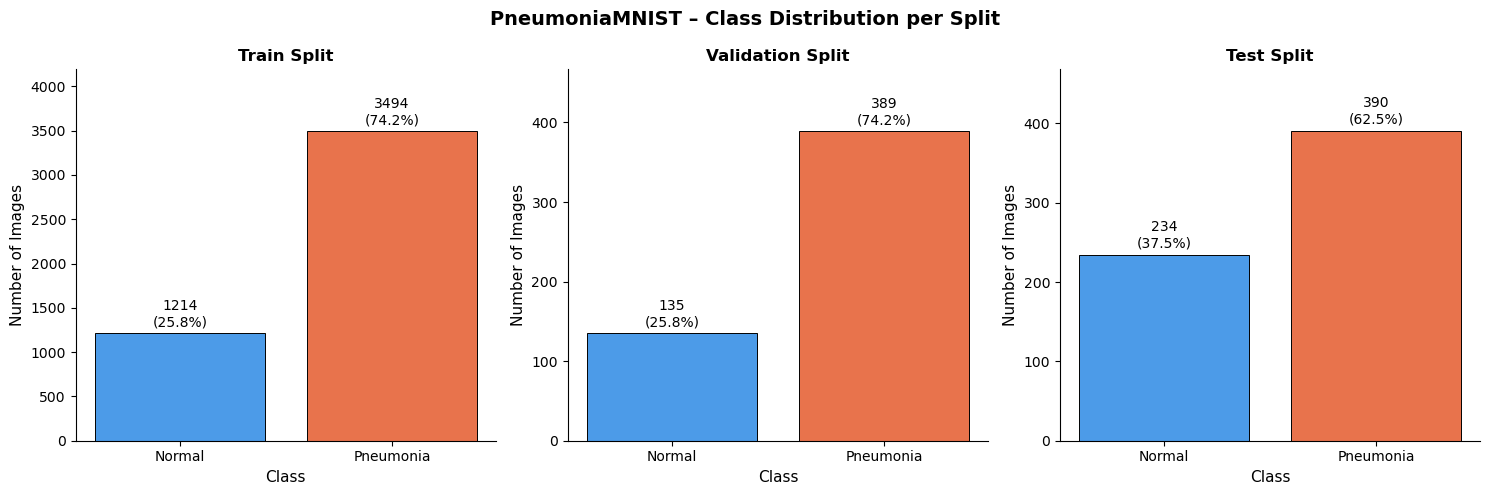


Class distribution summary:
Split             Normal   Pneumonia       Total
------------------------------------------------
Train               1214        3494        4708
Validation           135         389         524
Test                 234         390         624

Part 1 complete.


In [45]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
from torch.utils.data import DataLoader
from torchvision import transforms

import medmnist
from medmnist import INFO, PneumoniaMNIST   

# fix the output of the random numbe rgenerator so that reuslts are comparable 
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# this is the numbe rof image fed to the model in one go picking a numbe rthat is not to big or small 
BATCH_SIZE = 32

# dircetory where files will be stored
DATA_DIR = r"C:\Users\Student\Documents\tadala_main\HUB4049"
os.makedirs(DATA_DIR, exist_ok=True)

# asisgning labels that for 0 the cehst x-ray is normal for 1 it is pnemonia 
#CLASS_LABELS[1 ]= PNEMONIA CLASS_LABELS[0] = NORMAL
CLASS_LABELS = {0: "Normal", 1: "Pneumonia"}


# STEP 1A – MINIMAL TRANSFORMS FOR LOADING ONLY

# composing an orer of transformations to CxHxW
basic_transform = transforms.Compose([
    transforms.ToTensor(),   # rescales to [0, 1] normalizng values
])

#--------------------------------------------------------------------------------------
# STEP 1B – loading datasets splits

# MedMNIST contains its own splits so we dont need to make our own

print("Downloading / loading PneumoniaMNIST …")

# split='train'  → training set  (used to update model weights)
# split='val'    → validation set (used to monitor loss and trigger early stop)
# split='test'   → test set       (used only once for final evaluation)
# download=True  → fetches the .npz file if not already cached in DATA_DIR


# this creates training datset in to the repectable sets
# load images , load labels and manages splits
train_dataset = PneumoniaMNIST(split='train', transform=basic_transform,
                               download=True, root=DATA_DIR) 
# this set used during trainig to check model using for n monitoring purpose s
val_dataset   = PneumoniaMNIST(split='val',   transform=basic_transform,
                               download=True, root=DATA_DIR)
#this set is used at the very end in evalution of model peroformmnace 
test_dataset  = PneumoniaMNIST(split='test',  transform=basic_transform,
                               download=True, root=DATA_DIR)

#printing the results of the dtatasets 
print(f"  Training samples   : {len(train_dataset)}")
print(f"  Validation samples : {len(val_dataset)}")
print(f"  Test samples       : {len(test_dataset)}")

#--------------------------------------------------------------------------------
# STEP 1C – making dtatloaders which help with groupinng samples in to smaller smaples,
#shuffling to also prevent memorization. they help to then feed these smaller smaples

#taking soruce data from taraining  data set organizing it to match the batch size of 32 
#then ordering/shuffling the batches and procesisng them
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0)

# helps with consistent evaluatrion
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)

#sued for evaluation 
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)

#output results 
print(f"\nDataLoaders created with batch_size={BATCH_SIZE}")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")
print(f"  Test batches  : {len(test_loader)}")

#-------------------------------------------------------------------------

# STEP 1D – INSPECT A SINGLE BATCH
# invetsigating one batch of data to ensure everything is corrcet

sample_images, sample_labels = next(iter(train_loader))
print(f"\nSample batch → images shape : {sample_images.shape}")

# Expected: torch.Size([32, 1, 28, 28])
#   32  = batch size
#    1  = number of channels (greyscale X-ray)
#   28  = image height in pixels
#   28  = image width  in pixels

print(f"Sample batch → labels shape : {sample_labels.shape}")
print(f"Unique label values in batch : {sample_labels.unique().tolist()}")

# -----------------------------------------------------------------------------
# STEP 1E – want to then generate a visulaitaion example from ecah class
# so we can visually verify the dataset is corrcet

def show_class_examples(dataset, class_labels, n_per_class=8, save_path=None):
    """
    Display a grid of n_per_class example images for every class in the dataset.

    Parameters
    ----------
    dataset     : MedMNIST dataset object
    class_labels: dict mapping integer class index → string label name
    n_per_class : number of example images to show per class
    save_path   : if provided, saves the figure to this file path
    """
    # essentailly syaing n_classes = 2 as there are two items in class_labels 
    n_classes = len(class_labels)

    # Collect indices for each class label so we can sample from them
    class_indices = {c: [] for c in class_labels}
    # loop thorugh every image 
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        # MedMNIST labels are numpy arrays; extract the scalar value
        label_val = int(label.item()) if hasattr(label, 'item') else int(label)
        if label_val in class_indices: #grouping datasets 
            class_indices[label_val].append(idx)

    fig, axes = plt.subplots(n_classes, n_per_class,
                             figsize=(n_per_class * 1.5, n_classes * 2.2))
    fig.suptitle("PneumoniaMNIST – Example Images per Class",
                 fontsize=14, fontweight='bold', y=1.01)

    for row, (class_id, label_name) in enumerate(class_labels.items()):
        # Randomly pick n_per_class images from this class, helps to avoid reptition
        chosen = np.random.choice(class_indices[class_id],
                                  size=min(n_per_class, len(class_indices[class_id])),
                                  replace=False)
        
        for col, idx in enumerate(chosen): # ecah column is one image 
            img_tensor, _ = dataset[idx]
            # img_tensor shape: (1, H, W) , squeeze removes channel dimension,
            #numpy converts pytorch to numpy array 
            img_np = img_tensor.squeeze(0).numpy()

            ax = axes[row, col]
            ax.imshow(img_np, cmap='gray', interpolation='bilinear') # shows X-ray in grayscale 
            ax.axis('off')
            if col == 0:
                # Add class label on the left image of each row
                ax.set_ylabel(label_name, fontsize=11, rotation=0,
                              labelpad=50, va='center')

    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved → {save_path}")
    plt.show()


show_class_examples(train_dataset, CLASS_LABELS, n_per_class=8,
                    save_path = r"C:\Users\Student\Documents\tadala_main\HUB4049\fig1_class_examples.png")

# ------------------------------------------------------------------------------
# STEP 1F – VISUALISE CLASS DISTRIBUTION─
# helps to check dataset is balanced across classes and splits

def plot_class_distribution(datasets, dataset_names, class_labels,
                            save_path=None):
    """
    Plot side by side bar charts showing the number of images in each class
    for each data split (train, val, test).if one class dominates, a naive
    model can achieve high accuracy simply by always predicting the majority
    class.  This helps us identify whether we need to use class weights,
    oversampling, or other correction strategies. 

    Parameters
    ----------
    datasets      : list of MedMNIST dataset objects
    dataset_names : list of string names matching the datasets list
    class_labels  : dict mapping class index → label string
    save_path     : optional file path to save the figure
    """
    n_splits  = len(datasets) # numbe rof data sets 
    n_classes = len(class_labels) # nuumbers of classes 

    
    counts = np.zeros((n_splits, n_classes), dtype=int)
    for split_idx, dataset in enumerate(datasets):
        for _, label in dataset: # loops every image label pair 
            label_val = int(label.item()) if hasattr(label, 'item') else int(label) #ensure every assigned in an integer
            counts[split_idx, label_val] += 1

    fig, axes = plt.subplots(1, n_splits,
                             figsize=(5 * n_splits, 5), sharey=False)
    colors = ['#4C9BE8', '#E8734C']   # Blue = Normal, Orange = Pneumonia

    for ax, split_name, split_counts in zip(axes, dataset_names, counts):
        bars = ax.bar(list(class_labels.values()), split_counts, color=colors,
                      edgecolor='black', linewidth=0.7) # creates bar chart

        # Annotate each bar with the exact count and percentage
        total = split_counts.sum()
        for bar, count in zip(bars, split_counts):
            pct = 100 * count / total  # computes percentage
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + total * 0.01,
                    f"{count}\n({pct:.1f}%)",
                    ha='center', va='bottom', fontsize=10)

        ax.set_title(f"{split_name} Split", fontsize=12, fontweight='bold')
        ax.set_xlabel("Class", fontsize=11)
        ax.set_ylabel("Number of Images", fontsize=11)
        ax.set_ylim(0, split_counts.max() * 1.2)
        ax.spines[['top', 'right']].set_visible(False)

    fig.suptitle("PneumoniaMNIST – Class Distribution per Split",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved → {save_path}")
    plt.show()

    # Print a concise summary table
    print("\nClass distribution summary:")
    print(f"{'Split':<12}", end="")
    for label in class_labels.values():
        print(f"{label:>12}", end="")
    print(f"{'Total':>12}")
    print("-" * (12 + 12 * n_classes + 12))
    for split_name, split_counts in zip(dataset_names, counts):
        print(f"{split_name:<12}", end="")
        for c in split_counts:
            print(f"{c:>12}", end="")
        print(f"{split_counts.sum():>12}")


os.makedirs(r"C:\Users\Student\Documents\tadala_main\HUB4049", exist_ok=True)
plot_class_distribution(
    datasets=[train_dataset, val_dataset, test_dataset],
    dataset_names=["Train", "Validation", "Test"],
    class_labels=CLASS_LABELS,
    save_path = r"C:\Users\Student\Documents\tadala_main\HUB4049\fig1_class_examples.png"
)

print("\nPart 1 complete.")

## Step 2 : Preprocess data 
for this step we are concenred with computing the dataset level mean and standard dveiationn for normlaistaion. Then using this normalistaion for all images to have similar intensity. from there we can then asisgn the appropriate augementation transforms. Also rebuilding dataloaders with ful preprocesisng pipeline.then finally verify visually augemented images look meidcally sound. This is valuable as neural networks train more stable when the inputs have zero mean and unit variance. eithout this ther ecan be large gradients that destabilize the learning. so augementation helps to improve the learningby making the geometric and photmetric distortions more realistic.

Computing training set statistics …
  Training mean : [0.5719215869903564]
  Training std  : [0.1683512032032013]

Loading datasets with preprocessing transforms …
DataLoaders rebuilt with preprocessing.

Verification on first training batch after normalisation:
  Batch mean : -0.0843  (should be ≈ 0)
  Batch std  : 1.1362   (should be ≈ 1)
Figure saved → ./outputs/fig3_augmentation_examples.png


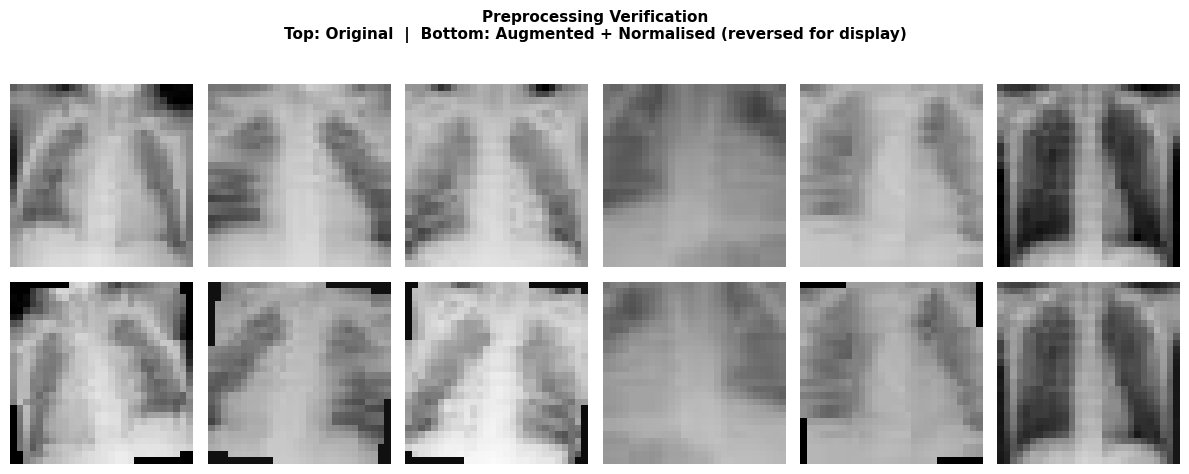


Part 2 complete.


In [46]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from torchvision import transforms

from medmnist import PneumoniaMNIST

#------------------------------------------------------------------------------------
# CONFIGURATION mmusst m atch that from step 1 
SEED       = 42
BATCH_SIZE = 32
DATA_DIR = r"C:\Users\Student\Documents\tadala_main\HUB4049"
os.makedirs(DATA_DIR, exist_ok=True)
torch.manual_seed(SEED)
np.random.seed(SEED)

# --------------------------------------------------------------
# STEP 2A – COMPUTE DATASET MEAN AND STANDARD DEVIATION


#we only calcyklate the mean and dts for the entire training set 


#we wnat to iterate over the dataset and compute teh per channel pixel mean and std dev
# for one channel this gives a scingle scale mean and std that can be used directly 
# effetcively does x_norm = (x-mew)/o
def compute_mean_std(dataset):
    """
    Returns
    -------
    mean : torch.Tensor, shape (C,)
    std  : torch.Tensor, shape (C,)
    """
    # DataLoader with a large batch of 256 so the loop is faster
    loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=0)

    # Running accumulators across all batches
    sum_pixels   = torch.zeros(1)   # sum of all pixel values per channel
    sum_sq_pixels = torch.zeros(1)  # sum of squared pixel values
    n_pixels     = 0                # total number of pixels for all images × HW

    for images, _ in loader:
        # images shape: (B, C, H, W)
        # Flatten H and W dimensions, keep B and C
        batch_pixels  = images.view(images.size(0), images.size(1), -1) #transforms (B,C,H,W) to (B,C,H*W)
        #making ecah channel a long vector of pixel values
        sum_pixels   += batch_pixels.sum(dim=[0, 2]) #sum of all pixels per channel 
        sum_sq_pixels += (batch_pixels ** 2).sum(dim=[0, 2]) #sum squared pixels per channel 
        n_pixels     += images.size(0) * images.size(2) * images.size(3) #total pixels = batch size*height*width
        

    mean = sum_pixels / n_pixels
    # Var(X) = E[X²] − E[X]²
    std  = torch.sqrt(sum_sq_pixels / n_pixels - mean ** 2)
    return mean, std


# Load train dataset with only the basic ToTensor transform for statistics
_raw_train = PneumoniaMNIST(split='train',
                            transform=transforms.ToTensor(),
                            download=True, root=DATA_DIR)

print("Computing training set statistics …")
DATASET_MEAN, DATASET_STD = compute_mean_std(_raw_train)
print(f"  Training mean : {DATASET_MEAN.tolist()}")
print(f"  Training std  : {DATASET_STD.tolist()}")

#---------------------------------------------------------------------------------
# STEP 2B – DEFINE AUGMENTATION TRANSFORMS

#  We deliberately EXCLUDE:
#    RandomVerticalFlip  – an upside-down lung is never seen in practice
#    Large rotations     – >15° is physiologically implausible
#    Colour transforms   – PneumoniaMNIST is greyscale; colour jitter on the
#                           other channels would be meaningless
#   • Random cropping to < ~80% of the image – would cut off critical anatomy
# Augmentation is applied ONLY to the training set.
#   Validation and test sets use only normalisation so that evaluation
#   metrics reflect performance on clean, unmodified images.

train_transform = transforms.Compose([
    # 1. Convert PIL image to FloatTensor in [0.0, 1.0]
    transforms.ToTensor(),

    # 2. Random horizontal flip – simulates left/right patient positioning
    #mimics natural vairation in patient positioning 
    #LATERAL X-RAYS SHOUDL NOT BE FLIPPED #
    transforms.RandomHorizontalFlip(p=0.5),   

    # 3. Small random rotation to account for patient tilt
    # Usually a minor rootation reflecting real world positioning 
    #when patient is not perfetcly centered
    transforms.RandomRotation(degrees=10),

    # 4. Brightness and contrast jitter – simulates scanner variation
    #    ColorJitter works on single-channel tensors too
    #small brightness contrast jitter simulates vaiation in exposure level across scanners
    transforms.ColorJitter(brightness=0.2, contrast=0.2),

    # 5. Normalise: subtract mean, divide by std
    #    After this, pixel values will have ~zero mean and unit std,
    #    which is what the network expects.
    transforms.Normalize(mean=DATASET_MEAN.tolist(),
                         std=DATASET_STD.tolist()),
])

# Validation and test transforms: only convert and normalise – no augmentation.
# Using the SAME mean and std as computed from the training set is critical.
val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=DATASET_MEAN.tolist(),
                         std=DATASET_STD.tolist()),
])

# -----------------------------------------------------------------------------------------
# STEP 2C – RELOAD DATASETS WITH FULL PREPROCESSING PIPELINE


print("\nLoading datasets with preprocessing transforms …")
# creates training dataset, each time an image is accessed the image is loaded,
# auugementation is rando,mly appluied nd normliztaion is applie d

train_dataset = PneumoniaMNIST(split='train', transform=train_transform,
                               download=True, root=DATA_DIR)
val_dataset   = PneumoniaMNIST(split='val',   transform=val_test_transform,
                               download=True, root=DATA_DIR)
test_dataset  = PneumoniaMNIST(split='test',  transform=val_test_transform,
                               download=True, root=DATA_DIR)

# Rebuild DataLoaders with the new transforms
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)

print("DataLoaders rebuilt with preprocessing.")

# -------------------------------------------
# STEP 2D – VERIFY NORMALISATION


# After normalisation the batch statistics should be close to mean≈0, std≈1.
# A significant deviation would indicate an error in the transform pipeline.
batch_images, _ = next(iter(train_loader))
print(f"\nVerification on first training batch after normalisation:")
print(f"  Batch mean : {batch_images.mean().item():.4f}  (should be ≈ 0)")
print(f"  Batch std  : {batch_images.std().item():.4f}   (should be ≈ 1)")

# -------------------------------------------------------------------------
# STEP 2E – VISUALISE AUGMENTED VS ORIGINAL IMAGES
# the preprocesisng verification stage 
# checking that augementation is working corrctely 
#checking normalization has been applie dcorrcetly 
#checking images still lookig meidcally realistic 

def denormalise(tensor, mean, std):
    """
    Reverse a Normalize transform so that images can be displayed.
    Clamps output to [0, 1] to handle floating-point edge cases.
    """
    mean_t = torch.tensor(mean).view(-1, 1, 1)
    std_t  = torch.tensor(std).view(-1, 1, 1)
    return (tensor * std_t + mean_t).clamp(0, 1)


def visualise_augmentations(raw_dataset, aug_dataset, n_samples=6,
                             mean=None, std=None, save_path=None):
    """
    Show the same images before (raw) and after (augmented + normalised)
    preprocessing side-by-side so we can verify augmentations look realistic.

    Parameters
    ----------
    raw_dataset : dataset with only ToTensor applied
    aug_dataset : dataset with full train_transform (augment + normalise)
    n_samples   : number of image pairs to display
    mean, std   : normalisation statistics used to reverse normalisation for display
    save_path   : optional path to save the figure
    """
    fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 2, 5))
    fig.suptitle("Preprocessing Verification\n"
                 "Top: Original  |  Bottom: Augmented + Normalised (reversed for display)",
                 fontsize=11, fontweight='bold')

    for col in range(n_samples):
        # Original image (only ToTensor applied)
        raw_img, label = raw_dataset[col]
        # Augmented image (full pipeline applied; the same index may look
        # different each run because augmentation is stochastic)
        aug_img, _     = aug_dataset[col]

        # Reverse normalisation so we can display the augmented image
        aug_img_display = denormalise(aug_img,
                                      mean=mean if mean else [0.0],
                                      std=std  if std  else [1.0])

        for row, (img, title) in enumerate([
            (raw_img.squeeze(0).numpy(), "Original"),
            (aug_img_display.squeeze(0).numpy(), "Augmented"),
        ]):
            ax = axes[row, col]
            ax.imshow(img, cmap='gray', vmin=0, vmax=1)
            ax.axis('off')
            if col == 0:
                ax.set_ylabel(title, fontsize=10, rotation=0,
                              labelpad=50, va='center')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved → {save_path}")
    plt.show()


# Raw dataset (no augmentation) for comparison
_raw_train_vis = PneumoniaMNIST(split='train',
                                transform=transforms.ToTensor(),
                                download=True, root=DATA_DIR)

visualise_augmentations(
    raw_dataset=_raw_train_vis,
    aug_dataset=train_dataset,
    n_samples=6,
    mean=DATASET_MEAN.tolist(),
    std=DATASET_STD.tolist(),
    save_path="./outputs/fig3_augmentation_examples.png"
)

# -----------------------------------------------------------------------------
# EXPORT: make these objects importable by subsequent parts

# When running as separate .py files, import these from this module:
#   from part2_preprocessing import (train_loader, val_loader, test_loader,
#                                     DATASET_MEAN, DATASET_STD)

print("\nPart 2 complete.")

## Step 3 : Build a simple convolutional neural network 
thei the bulding of the CNN architecture, we defien the brain of the project essentially, being the  neural network itself

In [47]:

#Import neural network tools
import torch
import torch.nn as nn  # nn = neural network building blocks

print("Neural network tools imported.")
# -----------------------------------------------------------------------------
# CELL 14: Define the SimpleCNN architecture
#
# Our network has this structure:
#
#   Input image (1 x 28 x 28)

#   Conv Layer 1 → ReLU → MaxPool    (28x28 → 14x14, 16 feature maps)

#   Conv Layer 2 → ReLU → MaxPool    (14x14 → 7x7, 32 feature maps)

#   Flatten                           (32 x 7 x 7 = 1568 numbers)

#   Fully Connected Layer 1 → ReLU   (1568 → 64)

#   Dropout                           (randomly zeros 50% of neurons)

#   Fully Connected Layer 2           (64 → 1)

#   Sigmoid                           (converts to probability 0–1)

#   Output: probability of Pneumonia
# -----------------------------------------------------------------------------

class SimpleCNN(nn.Module):

    def __init__(self):
        """
        __init__ runs once when you create the model.
        This is where you define all the layers.
        """
        super().__init__()   # starts up pytorch fucntionality such 
        #as parameter tarcking GPU support, ggradient computation 

       
        # convolution layer applies learnbale filters across the image 
        #filters like edges, textur,e curve
        # kernel_size=3 means each filter looks at a 3x3 patch of the image
        # padding=1 keeps the image the same size after the convolution

        # First conv layer: 1 input channel (grayscale)  16 feature maps
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16,
                               kernel_size=3, padding=1)

        # Second conv layer: 16 input channels  32 feature maps
        # Takes the 16 features from conv, layer 1 and builds more complex features
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32,
                               kernel_size=3, padding=1)

        # Third conv layer: 32 → 64 feature maps (optional but improves accuracy)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64,
                               kernel_size=3, padding=1)

        # --- POOLING LAYER ---
        # This shrinks the image by half each time it is applied
        # We define it once and reuse it after each conv layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- ACTIVATION FUNCTION ---
        # ReLU: if number is positive keep it, if negative set it to 0
        # Introduces non-linearity so the network can learn complex patterns
        self.relu = nn.ReLU()

        # --- DROPOUT LAYER ---
        # Randomly zeros out 50% of neurons during training
        # Forces the model to not rely too heavily on any single neuron
        # This is a regularisation technique to prevent overfitting
        # Dropout is automatically turned off during evaluation (model.eval())
        self.dropout = nn.Dropout(p=0.5)

        # --- FULLY CONNECTED LAYERS ---
        # After 3 rounds of conv + pool, image is 3x3 with 64 channels
        # Wait — let's calculate:
        #   Start:  28 x 28
        #   Pool 1: 14 x 14
        #   Pool 2:  7 x 7
        #   Pool 3:  3 x 3  (7/2 = 3.5, rounds down to 3)
        # So: 64 channels × 3 × 3 = 576 numbers going into fc1
        self.fc1 = nn.Linear(64 * 3 * 3, 128)   # 576 → 128
        self.fc2 = nn.Linear(128, 64)             # 128 → 64
        self.fc3 = nn.Linear(64, 1)               # 64  → 1 (final answer)

        # --- OUTPUT ACTIVATION ---
        # Sigmoid squashes any number into range 0–1 so it reads as a probability
        # 0 = definitely Normal, 1 = definitely Pneumonia
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        """
        forward() defines the order layers run when an image is passed through.
        x = one batch of images, shape: [batch_size, 1, 28, 28]
        Read each line inside-out: innermost operation happens first.
        """

        # --- FEATURE EXTRACTION STAGE ---

        # Pass through conv1, apply ReLU, then pool
        # Image goes from 28x28 to 14x14, channels: 1 to 16
        x = self.pool(self.relu(self.conv1(x)))

        # Pass through conv2, apply ReLU, then pool
        # Image goes from 14x14 to 7x7, channels: 16 →to32
        x = self.pool(self.relu(self.conv2(x)))

        # Pass through conv3, apply ReLU, then pool
        # Image goes from 7x7 → 3x3, channels: 32 → 64
        x = self.pool(self.relu(self.conv3(x)))

        # --- FLATTEN ---
        # Convert 3D block (64 x 3 x 3) into 1D list (576 numbers)
        # -1 tells PyTorch to figure out the batch dimension automatically
        x = x.view(-1, 64 * 3 * 3)

        # --- CLASSIFICATION STAGE ---

        # First fully connected layer + ReLU + Dropout
        x = self.relu(self.fc1(x))
        x = self.dropout(x)              # randomly zero 50% during training

        # Second fully connected layer + ReLU
        x = self.relu(self.fc2(x))

        # Final layer: compress to 1 number
        x = self.fc3(x)

        # Convert to probability between 0 and 1
        x = self.sigmoid(x)

        return x


# -----------------------------------------------------------------------------
# CELL 15: Creates the model and inspect it


# Set random seed for reproducibility before creating the model
# This ensures the model's initial weights are the same every run
torch.manual_seed(42)

# Instantiate the model — this runs __init__ and creates all the layers
model = SimpleCNN()

print("Model created successfully!\n")
print("=" * 50)
print("Model architecture:")
print("=" * 50)
print(model)


# -----------------------------------------------------------------------------
# CELL 16: Count the total number of trainable parameters
#
# Parameters are the numbers inside the model that get updated during training.
# More parameters = more powerful but also more likely to overfit.
# This gives you a sense of how complex the model is.


total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel parameters:")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")


# -----------------------------------------------------------------------------
# CELL 17: test forward pass to verify the model works
# Before training, always check that one batch can pass through without errors.
# This catches shape mismatches and other bugs early.


# Create a fake batch of 4 images (4 x 1 channel x 28x28 pixels)
# torch.randn creates random numbers — we just need something the right shape
dummy_input = torch.randn(4, 1, 28, 28)

# Pass it through the model
with torch.no_grad():   # no_grad = don't track gradients, just testing
    dummy_output = model(dummy_input)

print(f"\nTest forward pass:")
print(f"  Input shape:  {dummy_input.shape}")    # [4, 1, 28, 28]
print(f"  Output shape: {dummy_output.shape}")   # [4, 1]
print(f"  Output values (probabilities): {dummy_output.squeeze().tolist()}")
print(f"  All values between 0 and 1: {bool((dummy_output >= 0).all() and (dummy_output <= 1).all())}")
print("\nIf output shape is [4, 1] and values are between 0–1, the model is working correctly.")
print("\nPart 3 complete ")

Neural network tools imported.
Model created successfully!

Model architecture:
SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=576, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Model parameters:
  Total parameters:     105,473
  Trainable parameters: 105,473

Test forward pass:
  Input shape:  torch.Size([4, 1, 28, 28])
  Output shape: torch.Size([4, 1])
  Output values (probabilities): [0.4833620488643646, 0.47144508361816406, 0.48236560821533203, 0.47350120544433594]
  All values between 0 and 1:

## Step 4 : Train the network
This step trains the CNN defined inn part 3

Loss function: Binary Cross-Entropy Loss (BCELoss)
Optimiser:     Adam (lr=0.001)
Scheduler:     ReduceLROnPlateau (halves lr if no improvement for 5 epochs)

Early stopping: will stop if no improvement for 10 consecutive epochs.

Starting training for up to 50 epochs...
Epoch [  1/50]  Train Loss: 0.3674  |  Val Loss: 0.1832
Epoch [  2/50]  Train Loss: 0.2102  |  Val Loss: 0.1378
    ✓ Validation loss improved to 0.1378
Epoch [  3/50]  Train Loss: 0.1740  |  Val Loss: 0.1210
    ✓ Validation loss improved to 0.1210
Epoch [  4/50]  Train Loss: 0.1370  |  Val Loss: 0.1168
    ✓ Validation loss improved to 0.1168
Epoch [  5/50]  Train Loss: 0.1232  |  Val Loss: 0.1017
    ✓ Validation loss improved to 0.1017
Epoch [  6/50]  Train Loss: 0.1241  |  Val Loss: 0.1271
    ✗ No improvement for 1/10 epochs
Epoch [  7/50]  Train Loss: 0.1128  |  Val Loss: 0.1212
    ✗ No improvement for 2/10 epochs
Epoch [  8/50]  Train Loss: 0.1089  |  Val Loss: 0.1059
    ✗ No improvement for 3/10 epochs
Epoch

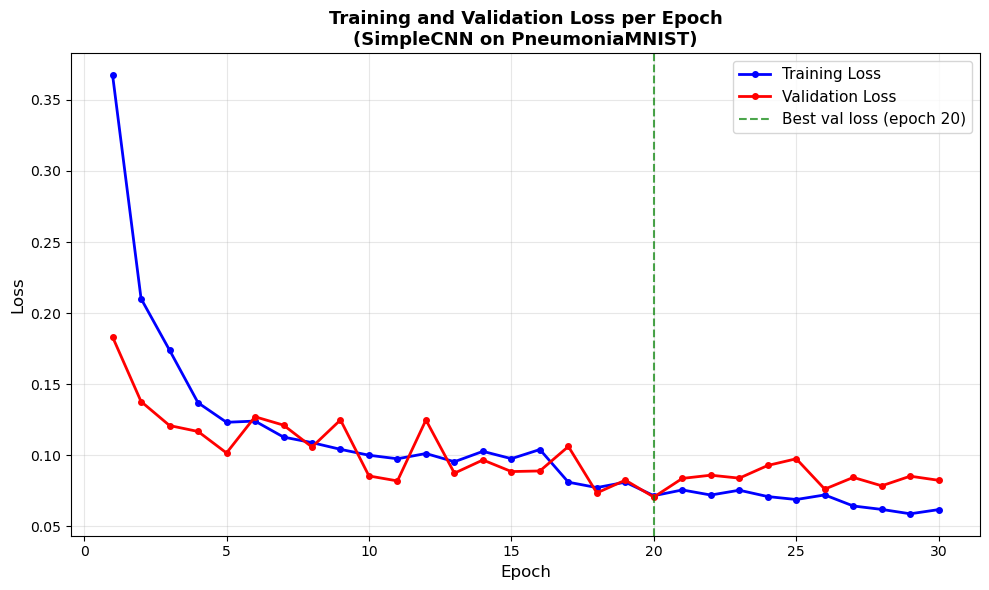

Training curves saved as 'training_curves.png'

Part 4 complete


In [48]:

# -----------------------------------------------------------------------------
# CELL 18: Set up the loss function and optimiser
#
# loss function = measures how wrong the model is each batch
# optimiser     = uses that error to update the model's weights
# -----------------------------------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
# This ensures training results are the same every run (as required by project)
torch.manual_seed(42)

# Loss function: Binary Cross-Entropy Loss
# Used for binary (two-class) classification problems
# Compares model output (0–1 probability) against true label (0 or 1)
# Small loss = model was right, Large loss = model was wrong
criterion = nn.BCELoss()

# Optimiser: Adam
# Adam is a smart version of gradient descent that automatically adjusts
# how big each weight update is. lr = learning rate (step size).
# lr=0.001 is a well-tested default — don't change it until the model works first
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Optional: Learning rate scheduler
# Reduces the learning rate by half if validation loss doesn't improve for 5 epochs
# This helps the model make finer adjustments later in training
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                  factor=0.5, patience=5)

print("Loss function: Binary Cross-Entropy Loss (BCELoss)")
print(f"Optimiser:     Adam (lr={optimizer.param_groups[0]['lr']})")
print("Scheduler:     ReduceLROnPlateau (halves lr if no improvement for 5 epochs)")


# -----------------------------------------------------------------------------
# CELL 19: Define early stopping
#


class EarlyStopping:
    """
    Monitors validation loss and stops training if it stops improving.

    patience  = how many epochs to wait for improvement before stopping
    min_delta = minimum change that counts as an improvement
    """

    def __init__(self, patience=10, min_delta=0.001):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0          # how many epochs since last improvement
        self.best_loss  = None       # best validation loss seen so far
        self.stop       = False      # flag that signals training to stop

    def __call__(self, val_loss):
        if self.best_loss is None:
            # First epoch — just record the loss
            self.best_loss = val_loss

        elif val_loss < self.best_loss - self.min_delta:
            # Validation loss improved — reset counter
            self.best_loss = val_loss
            self.counter   = 0
            print(f"    ✓ Validation loss improved to {val_loss:.4f}")

        else:
            # No improvement — increment counter
            self.counter += 1
            print(f"    ✗ No improvement for {self.counter}/{self.patience} epochs")
            if self.counter >= self.patience:
                self.stop = True
                print(f"\n>>> Early stopping triggered after {self.patience} epochs without improvement.")


early_stopping = EarlyStopping(patience=10, min_delta=0.001)
print(f"\nEarly stopping: will stop if no improvement for 10 consecutive epochs.")


# -----------------------------------------------------------------------------
# CELL 20: The training loop.
# For each epoch:
#   1. Train: loop through all training batches, update weights
#   2. Validate: loop through validation batches, measure performance (no updates)
#   3. Record losses, check early stopping
# -----------------------------------------------------------------------------

# Lists to store loss values for plotting later
train_losses = []
val_losses   = []

# How many epochs to run at most (early stopping may end it sooner)
MAX_EPOCHS = 50

print(f"\nStarting training for up to {MAX_EPOCHS} epochs...")
print("=" * 65)

for epoch in range(MAX_EPOCHS):

    # -------------------------------------------------------------------------
    # TRAINING PHASE
    # model.train() switches on training behaviour (dropout active etc.)
    # -------------------------------------------------------------------------
    model.train()
    running_loss = 0.0   # accumulates total loss across all batches this epoch

    for batch_idx, (images, labels) in enumerate(train_loader):

        # Step 1: Clear gradients from the previous batch
        # Must do this every batch — PyTorch accumulates gradients by default
        optimizer.zero_grad()

        # Step 2: Forward pass — feed images through the network
        # .squeeze() removes the extra dimension: [32, 1] → [32]
        outputs = model(images).squeeze()

        # Step 3: Calculate how wrong the model was on this batch
        # labels.float() converts integer labels to floats (BCELoss requires this)
        loss = criterion(outputs, labels.float().squeeze())

        # Step 4: Backpropagation — calculate gradients
        # Traces back through the network assigning blame to each weight
        loss.backward()

        # Step 5: Update weights using the gradients
        # This is the moment the model actually learns
        optimizer.step()

        # Add this batch's loss to the running total
        running_loss += loss.item()

    # Calculate average training loss for this epoch
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # -------------------------------------------------------------------------
    # VALIDATION PHASE
    # model.eval() switches off training behaviour (dropout disabled etc.)
    # torch.no_grad() tells PyTorch not to track gradients — saves memory/time
    # -------------------------------------------------------------------------
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images).squeeze()
            loss    = criterion(outputs, labels.float().squeeze())
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Update learning rate scheduler based on validation loss
    scheduler.step(avg_val_loss)

    # Print progress for this epoch
    print(f"Epoch [{epoch+1:3d}/{MAX_EPOCHS}]  "
          f"Train Loss: {avg_train_loss:.4f}  |  "
          f"Val Loss: {avg_val_loss:.4f}")

    # Check early stopping — will set early_stopping.stop = True if triggered
    early_stopping(avg_val_loss)
    if early_stopping.stop:
        print(f"\nTraining stopped at epoch {epoch+1}.")
        break

print("\n" + "=" * 65)
print(f"Training complete. Ran for {len(train_losses)} epochs.")
print(f"Best validation loss: {min(val_losses):.4f} at epoch {val_losses.index(min(val_losses))+1}")


# -----------------------------------------------------------------------------
# CELL 21: Save the trained model
# -----------------------------------------------------------------------------

torch.save(model.state_dict(), 'simple_cnn_weights.pth')
print("\nModel weights saved to 'simple_cnn_weights.pth'")
print("To reload: model.load_state_dict(torch.load('simple_cnn_weights.pth'))")


# -----------------------------------------------------------------------------
# CELL 22: Plot training and validation loss curves

#   GOOD: Both curves going downward together
#   OVERFIT: Training keeps going down but validation goes back up
#   UNDERFIT: Both curves are high and barely moving


epochs_run = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_run, train_losses, 'b-o', markersize=4, label='Training Loss',   linewidth=2)
plt.plot(epochs_run, val_losses,   'r-o', markersize=4, label='Validation Loss', linewidth=2)

# Mark the best validation loss
best_epoch = val_losses.index(min(val_losses)) + 1
plt.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7,
            label=f'Best val loss (epoch {best_epoch})')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss',  fontsize=12)
plt.title('Training and Validation Loss per Epoch\n(SimpleCNN on PneumoniaMNIST)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved as 'training_curves.png'")
print("\nPart 4 complete")

## Step5 : Evaluation 

Evaluation libraries imported successfully.
Test set evaluation complete.
Total test images: 624
Actual Pneumonia:  390
Actual Normal:     234

         MODEL PERFORMANCE ON TEST SET
  Accuracy:     0.8654  (86.54%)
  Sensitivity:  0.9974  (99.74%)
  Specificity:  0.6453  (64.53%)
  Precision:    0.8242  (82.42%)
  F1 Score:     0.9026
  AUC Score:    0.9586

Confusion Matrix breakdown:
  True  Positives (TP): 389  — Pneumonia correctly detected
  True  Negatives (TN): 151  — Normal correctly identified
  False Positives (FP): 83  — Normal wrongly flagged as Pneumonia
  False Negatives (FN): 1  — Pneumonia missed (most dangerous error)

Full classification report:
               precision    recall  f1-score   support

   Normal (0)       0.99      0.65      0.78       234
Pneumonia (1)       0.82      1.00      0.90       390

     accuracy                           0.87       624
    macro avg       0.91      0.82      0.84       624
 weighted avg       0.89      0.87      0.86      

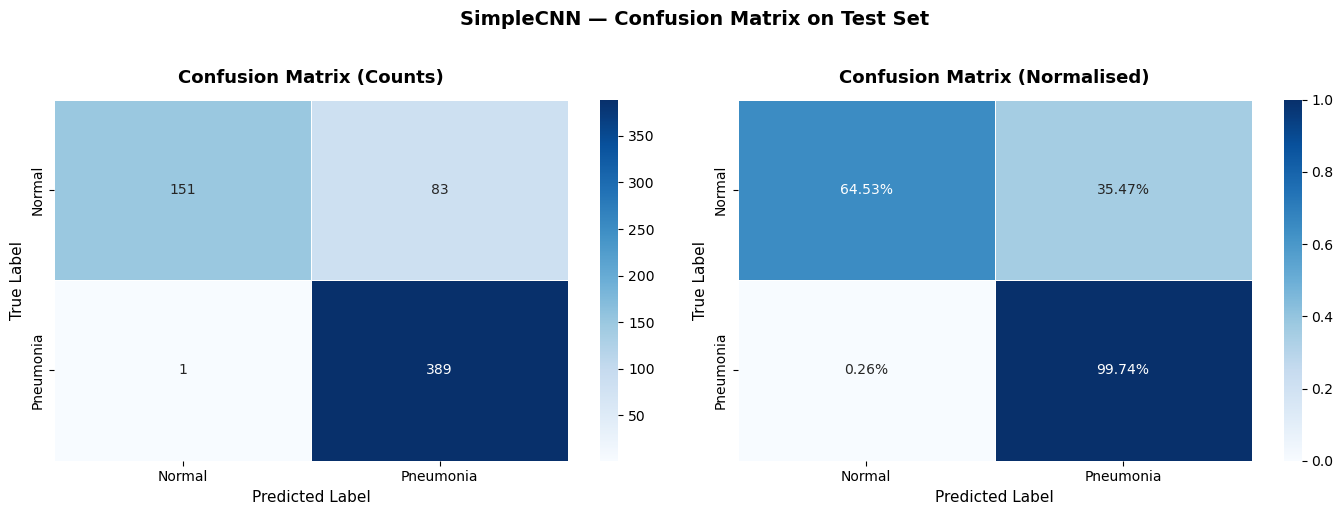

Confusion matrix saved as 'confusion_matrix.png'


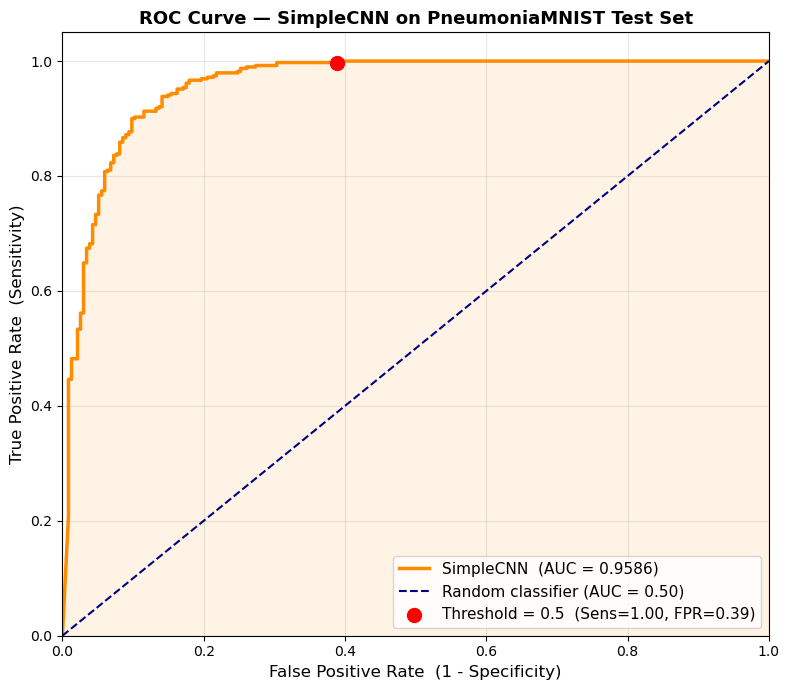

ROC curve saved as 'roc_curve.png'
AUC Score: 0.9586


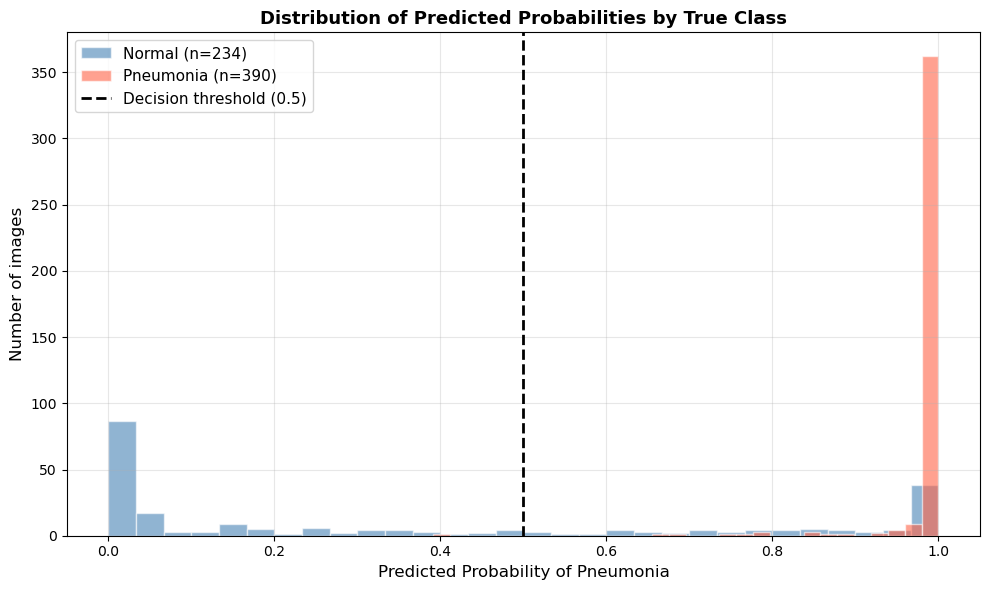

Probability distribution saved as 'probability_distribution.png'


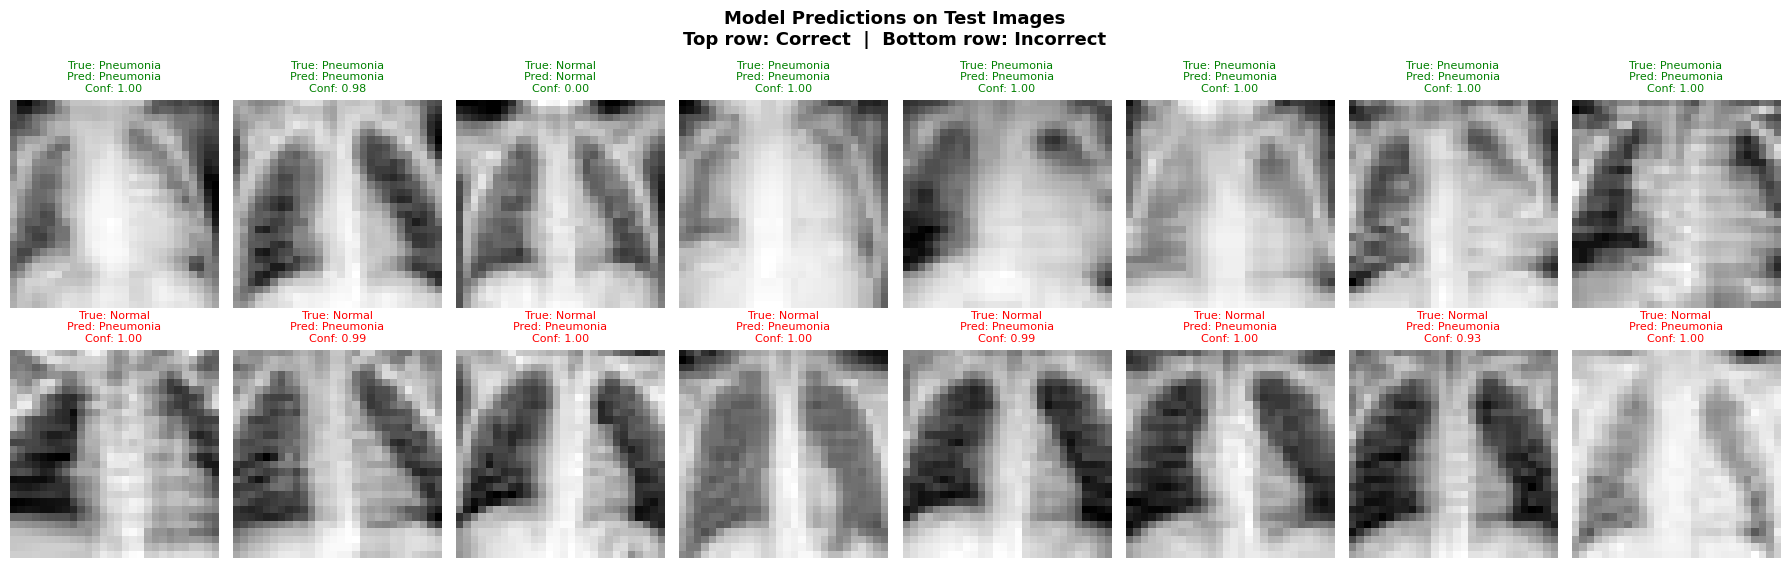

Prediction examples saved as 'prediction_examples.png'


       FINAL EVALUATION REPORT — SimpleCNN
       Dataset: PneumoniaMNIST (Chest X-Ray)

  Test set size:   624 images
  Normal cases:    234 (37.5%)
  Pneumonia cases: 390 (62.5%)

  --- Performance Metrics ---
  Accuracy:        0.8654   (86.54%)
  Sensitivity:     0.9974   (99.74%)
  Specificity:     0.6453   (64.53%)
  Precision:       0.8242   (82.42%)
  F1 Score:        0.9026
  AUC Score:       0.9586

  --- Confusion Matrix ---
  True  Positives (TP):  389  Pneumonia correctly detected
  True  Negatives (TN):  151  Normal correctly identified
  False Positives (FP):   83  Normal wrongly flagged as Pneumonia
  False Negatives (FN):    1  Pneumonia cases missed  ← critical

  --- Files Saved ---
  confusion_matrix.png
  roc_curve.png
  probability_distribution.png
  prediction_examples.png

Part 5 complete


In [49]:

#   - Accuracy
#   - Sensitivity (Recall)
#   - Specificity
#   - Precision
#   - F1 Score
#   - Confusion Matrix
#   - ROC Curve + AUC Score

# -----------------------------------------------------------------------------
# CELL 23: Import evaluation tools
# -----------------------------------------------------------------------------
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.metrics import (
    accuracy_score,           # percentage of correct predictions
    confusion_matrix,         # 2x2 table of TP, TN, FP, FN
    classification_report,    # precision, recall, f1 in one table
    roc_curve,                # false positive rate vs true positive rate
    roc_auc_score,            # single number summarising the ROC curve
    precision_score,          # of all predicted positives, how many were right
    recall_score,             # of all actual positives, how many did we catch
    f1_score                  # harmonic mean of precision and recall
)

import seaborn as sns         # makes nicer looking confusion matrix plots
# If seaborn is not installed run: pip install seaborn

print("Evaluation libraries imported successfully.")


# -----------------------------------------------------------------------------
# CELL 24: Run the model on the entire test set

#   all_labels  = the TRUE labels (what the images actually are)
#   all_probs   = the model's RAW output (probability between 0 and 1)
#   all_preds   = the model's DECISION (0 or 1, based on 0.5 threshold)

#   - preds  are used for accuracy, confusion matrix, sensitivity etc.
#   - probs  are used for the ROC curve (which needs continuous values)


# Put model into evaluation mode
# This disables dropout so predictions are consistent
model.eval()

all_labels = []   # true labels
all_probs  = []   # raw probability outputs from sigmoid
all_preds  = []   # final 0 or 1 decisions

# Loop through the test set — torch.no_grad() saves memory and time
# because we are not training, just measuring
with torch.no_grad():
    for images, labels in test_loader:

        # Forward pass — get probability outputs
        outputs = model(images).squeeze()   # shape: [batch_size]

        # Convert probability to binary prediction using 0.5 threshold
        # If probability >= 0.5 → predict Pneumonia (1)
        # If probability <  0.5 → predict Normal (0)
        predictions = (outputs >= 0.5).float()

        # Collect results from this batch
        all_probs.extend(outputs.cpu().numpy())
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy().flatten())

# Convert to numpy arrays for sklearn functions
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)

print(f"Test set evaluation complete.")
print(f"Total test images: {len(all_labels)}")
print(f"Actual Pneumonia:  {all_labels.sum().astype(int)}")
print(f"Actual Normal:     {(all_labels == 0).sum()}")


# -----------------------------------------------------------------------------
# CELL 25: Calculate all core metrics
#
# ACCURACY     = (correct predictions) / (total predictions)
#                Simple but misleading on imbalanced datasets
#
# SENSITIVITY  = (true positives) / (true positives + false negatives)
# Also called RECALL or TRUE POSITIVE RATE
#                Of all ACTUAL pneumonia cases, what % did we correctly detect?
#                This is the most clinically important metric —
#                missing a sick patient (false negative) is dangerous
#
# SPECIFICITY  = (true negatives) / (true negatives + false positives)
# Also called TRUE NEGATIVE RATE
#                Of all ACTUAL normal cases, what % did we correctly identify?
#                High specificity = few healthy patients wrongly alarmed
#
# PRECISION    = (true positives) / (true positives + false positives)
#                Of all cases we PREDICTED as pneumonia, what % actually had it?
#
# F1 SCORE     = harmonic mean of precision and recall
#                Good single number when dataset is imbalanced
#                Balances both false positives and false negatives
#
# AUC          = Area Under the ROC Curve
#                0.5 = random guessing, 1.0 = perfect classifier


# Core metrics
accuracy    = accuracy_score(all_labels, all_preds)
sensitivity = recall_score(all_labels, all_preds)          # recall = sensitivity
precision   = precision_score(all_labels, all_preds)
f1          = f1_score(all_labels, all_preds)
auc         = roc_auc_score(all_labels, all_probs)

# Calculate specificity manually from confusion matrix
# Confusion matrix layout:
#                  Predicted Normal  Predicted Pneumonia
# Actual Normal  [  TN              FP  ]
# Actual Pneumonia [ FN             TP  ]
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()   # unpack all four values

specificity = tn / (tn + fp)

# Print a clean summary table
print("\n" + "=" * 50)
print("         MODEL PERFORMANCE ON TEST SET")
print("=" * 50)
print(f"  Accuracy:     {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Sensitivity:  {sensitivity:.4f}  ({sensitivity*100:.2f}%)")
print(f"  Specificity:  {specificity:.4f}  ({specificity*100:.2f}%)")
print(f"  Precision:    {precision:.4f}  ({precision*100:.2f}%)")
print(f"  F1 Score:     {f1:.4f}")
print(f"  AUC Score:    {auc:.4f}")
print("=" * 50)
print(f"\nConfusion Matrix breakdown:")
print(f"  True  Positives (TP): {tp}  — Pneumonia correctly detected")
print(f"  True  Negatives (TN): {tn}  — Normal correctly identified")
print(f"  False Positives (FP): {fp}  — Normal wrongly flagged as Pneumonia")
print(f"  False Negatives (FN): {fn}  — Pneumonia missed (most dangerous error)")

# Full sklearn classification report
print("\nFull classification report:")
print(classification_report(all_labels, all_preds,
                             target_names=['Normal (0)', 'Pneumonia (1)']))


# -----------------------------------------------------------------------------
# CELL 26: Plot the Confusion Matrix


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Raw counts ---
sns.heatmap(cm,
            annot=True,
            fmt='d',                          # integer format
            cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'],
            ax=axes[0],
            linewidths=0.5,
            cbar=True)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label',      fontsize=11)

# --- Right: Normalised percentages ---
cm_normalised = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalised,
            annot=True,
            fmt='.2%',                        # percentage format
            cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'],
            ax=axes[1],
            linewidths=0.5,
            vmin=0, vmax=1,
            cbar=True)
axes[1].set_title('Confusion Matrix (Normalised)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label',      fontsize=11)

plt.suptitle('SimpleCNN — Confusion Matrix on Test Set',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved as 'confusion_matrix.png'")


# -----------------------------------------------------------------------------
# CELL 27: Plot the ROC Curve

# ROC = Receiver Operating Characteristic curve
# plots Sensitivity (True Positive Rate) on the y-axis against
# 1 - Specificity (False Positive Rate) on the x-axis at every
# possible threshold value between 0 and 1.
#
# The diagonal dashed line represents a random classifier (AUC = 0.5)
# Your model's curve should bow towards the top-left corner.
# The closer it hugs that corner, the better the model.
# AUC (Area Under the Curve):
#   0.5  = no better than random guessing
#   0.7  = acceptable
#   0.8  = good
#   0.9  = excellent
#   1.0  = perfect (suspicious — probably overfitting)


fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

plt.figure(figsize=(8, 7))

# Plot the ROC curve
plt.plot(fpr, tpr,
         color='darkorange',
         linewidth=2.5,
         label=f'SimpleCNN  (AUC = {auc:.4f})')

# Plot the diagonal — this is what a random classifier looks like
plt.plot([0, 1], [0, 1],
         color='navy',
         linewidth=1.5,
         linestyle='--',
         label='Random classifier (AUC = 0.50)')

# Mark the operating point at threshold = 0.5
# Find the threshold closest to 0.5
idx = np.argmin(np.abs(thresholds - 0.5))
plt.scatter(fpr[idx], tpr[idx],
            color='red', s=100, zorder=5,
            label=f'Threshold = 0.5  (Sens={tpr[idx]:.2f}, FPR={fpr[idx]:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate  (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate  (Sensitivity)',      fontsize=12)
plt.title('ROC Curve — SimpleCNN on PneumoniaMNIST Test Set',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)

# Shade the area under the curve
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"ROC curve saved as 'roc_curve.png'")
print(f"AUC Score: {auc:.4f}")


# -----------------------------------------------------------------------------
# CELL 28: Plot the probability distribution
#
# This shows how confident the model is about its predictions.
# Two histograms overlaid:
#   Blue  = probabilities assigned to actual Normal images
#   Red   = probabilities assigned to actual Pneumonia images
#
# A well-trained model will show:
#   - Blue histogram pushed towards 0 (correctly low confidence for Normal)
#   - Red histogram pushed towards 1 (correctly high confidence for Pneumonia)
#
# Overlapping histograms = the model is uncertain in that region
# -----------------------------------------------------------------------------

normal_probs    = all_probs[all_labels == 0]   # probabilities for actual Normal
pneumonia_probs = all_probs[all_labels == 1]   # probabilities for actual Pneumonia

plt.figure(figsize=(10, 6))

plt.hist(normal_probs,
         bins=30,
         alpha=0.6,
         color='steelblue',
         label=f'Normal (n={len(normal_probs)})',
         edgecolor='white')

plt.hist(pneumonia_probs,
         bins=30,
         alpha=0.6,
         color='tomato',
         label=f'Pneumonia (n={len(pneumonia_probs)})',
         edgecolor='white')

# Mark the decision threshold
plt.axvline(x=0.5,
            color='black',
            linestyle='--',
            linewidth=2,
            label='Decision threshold (0.5)')

plt.xlabel('Predicted Probability of Pneumonia', fontsize=12)
plt.ylabel('Number of images',                   fontsize=12)
plt.title('Distribution of Predicted Probabilities by True Class',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('probability_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Probability distribution saved as 'probability_distribution.png'")


# -----------------------------------------------------------------------------
# CELL 29: Visualise correct and incorrect predictions
#
# This shows actual test images alongside the model's prediction and
# confidence score. Seeing WHERE the model fails is very useful for
# your report discussion section.
# -----------------------------------------------------------------------------

# Reload test dataset without transforms for clean display
from medmnist import PneumoniaMNIST
import torchvision.transforms as transforms

display_transform = transforms.ToTensor()
display_dataset   = PneumoniaMNIST(split='test', download=True,
                                    transform=display_transform)
display_loader    = torch.utils.data.DataLoader(display_dataset,
                                                 batch_size=64,
                                                 shuffle=False)

# Collect predictions on display_loader
display_images_list = []
display_labels_list = []
display_probs_list  = []
display_preds_list  = []

model.eval()
with torch.no_grad():
    for images, labels in display_loader:
        # Normalise for model input using same stats as training
        normalise = transforms.Normalize(
        mean=DATASET_MEAN.tolist(),
        std=DATASET_STD.tolist())
        images_norm = torch.stack([normalise(img) for img in images])

        outputs     = model(images_norm).squeeze()
        predictions = (outputs >= 0.5).float()

        display_images_list.append(images)
        display_labels_list.extend(labels.numpy().flatten())
        display_probs_list.extend(outputs.numpy())
        display_preds_list.extend(predictions.numpy())

display_images = torch.cat(display_images_list, dim=0)
display_labels = np.array(display_labels_list)
display_probs  = np.array(display_probs_list)
display_preds  = np.array(display_preds_list)

# Find correct and incorrect predictions
correct_idx   = np.where(display_labels == display_preds)[0]
incorrect_idx = np.where(display_labels != display_preds)[0]

# Show 8 correct + 8 incorrect predictions
n_show = min(8, len(correct_idx), len(incorrect_idx))

fig, axes = plt.subplots(2, n_show, figsize=(18, 6))
fig.suptitle('Model Predictions on Test Images\n'
             'Top row: Correct  |  Bottom row: Incorrect',
             fontsize=13, fontweight='bold')

class_names = ['Normal', 'Pneumonia']
colors      = {'correct': 'green', 'incorrect': 'red'}

for i in range(n_show):

    # --- Top row: Correct predictions ---
    idx   = correct_idx[i]
    image = display_images[idx].squeeze()
    true  = int(display_labels[idx])
    prob  = display_probs[idx]
    pred  = int(display_preds[idx])

    axes[0, i].imshow(image, cmap='gray')
    axes[0, i].set_title(
        f'True: {class_names[true]}\n'
        f'Pred: {class_names[pred]}\n'
        f'Conf: {prob:.2f}',
        fontsize=8, color='green'
    )
    axes[0, i].axis('off')

    # --- Bottom row: Incorrect predictions ---
    idx   = incorrect_idx[i]
    image = display_images[idx].squeeze()
    true  = int(display_labels[idx])
    prob  = display_probs[idx]
    pred  = int(display_preds[idx])

    axes[1, i].imshow(image, cmap='gray')
    axes[1, i].set_title(
        f'True: {class_names[true]}\n'
        f'Pred: {class_names[pred]}\n'
        f'Conf: {prob:.2f}',
        fontsize=8, color='red'
    )
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('prediction_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Prediction examples saved as 'prediction_examples.png'")


# -----------------------------------------------------------------------------
# CELL 30: Final summary report — everything in one place


print("\n")
print("=" * 60)
print("       FINAL EVALUATION REPORT — SimpleCNN")
print("       Dataset: PneumoniaMNIST (Chest X-Ray)")
print("=" * 60)
print(f"\n  Test set size:   {len(all_labels)} images")
print(f"  Normal cases:    {(all_labels == 0).sum()} ({100*(all_labels==0).mean():.1f}%)")
print(f"  Pneumonia cases: {(all_labels == 1).sum()} ({100*(all_labels==1).mean():.1f}%)")
print(f"\n  --- Performance Metrics ---")
print(f"  Accuracy:        {accuracy:.4f}   ({accuracy*100:.2f}%)")
print(f"  Sensitivity:     {sensitivity:.4f}   ({sensitivity*100:.2f}%)")
print(f"  Specificity:     {specificity:.4f}   ({specificity*100:.2f}%)")
print(f"  Precision:       {precision:.4f}   ({precision*100:.2f}%)")
print(f"  F1 Score:        {f1:.4f}")
print(f"  AUC Score:       {auc:.4f}")
print(f"\n  --- Confusion Matrix ---")
print(f"  True  Positives (TP): {tp:4d}  Pneumonia correctly detected")
print(f"  True  Negatives (TN): {tn:4d}  Normal correctly identified")
print(f"  False Positives (FP): {fp:4d}  Normal wrongly flagged as Pneumonia")
print(f"  False Negatives (FN): {fn:4d}  Pneumonia cases missed  ← critical")
print(f"\n  --- Files Saved ---")
print(f"  confusion_matrix.png")
print(f"  roc_curve.png")
print(f"  probability_distribution.png")
print(f"  prediction_examples.png")
print("=" * 60)
print("\nPart 5 complete")
